필요한 서드 파티 라이브러리

In [2]:
# import 부분
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import os
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, 
    precision_score, recall_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import cv2



In [3]:
# 전처리 파트   
from torch.utils.data import random_split

# 경로 설정
food_dir = './images'
train_dir = './data/dataset/train'
test_dir = './data/dataset/test'

# Case 1
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.15, saturation=0.1, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),

        transforms.RandomApply([
            transforms.ColorJitter(contrast=0.3)
        ], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# Case 2
data_transforms = {
    'train': transforms.Compose([         
    transforms.Resize((224, 224)),         
    transforms.RandomHorizontalFlip(p=0.5),         
    transforms.RandomRotation(degrees=15),         
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),         
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),         
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])     
    ]),     
    
    'val': transforms.Compose([         
        transforms.Resize((224, 224)),         
        transforms.ToTensor(),         
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])     
        ]),    
            
    'test': transforms.Compose([         
        transforms.Resize((224, 224)),         
        transforms.ToTensor(),         
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225])     
            ])
    } 

# 전체 훈련 데이터셋(val이 없기 때문에 train_dir에서 직접 로드)
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])

# Train-Validation 분할 | 80:20
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, temp_val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Validation 데이터셋에서 transform을 적용하는 클래스 정의
class TransformDataset:
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # 원본 데이터에서 이미지와 레이블 가져오기
        original_dataset = self.dataset.dataset
        actual_idx = self.dataset.indices[idx]
        img_path, label = original_dataset.samples[actual_idx]
        
        # Image로 로드
        from PIL import Image
        img = Image.open(img_path).convert('RGB')
        
        # 새로운 transform 적용
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Validation 데이터셋 데이터 로더 생성
validation_dataset = TransformDataset(temp_val_dataset, data_transforms['val'])

# 테스트 데이터셋
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# 데이터로더
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 클래스 정보
class_names = full_train_dataset.classes
num_classes = len(class_names)

# 데이터셋 크기 확인
print(f"전체 훈련 데이터: {len(full_train_dataset)}")
print(f"훈련 데이터: {len(train_dataset)}")
print(f"검증 데이터: {len(validation_dataset)}")
print(f"테스트 데이터: {len(test_dataset)}")

전체 훈련 데이터: 35444
훈련 데이터: 28355
검증 데이터: 7089
테스트 데이터: 24204


Preprocessing Parameter Comparison
Transform Type       | Case 1 (90%)    | Case 2 (95%)    | Change    
-------------------- | --------------- | --------------- | ----------
RandomHorizontalFlip | p=0.3 (30%)     | p=0.5 (50%)     | +67%      
RandomRotation       | ±10 degrees     | ±15 degrees     | +50%      
ColorJitter - brightness | 0.1             | 0.2             | +100%     
ColorJitter - contrast | 0.15            | 0.2             | +33%      
ColorJitter - saturation | 0.1             | 0.2             | +100%     
ColorJitter - hue    | 0.05            | 0.1             | +100%     
RandomAffine - translate | (0.05, 0.05)    | (0.1, 0.1)      | +100%     
RandomAffine - scale | (0.95, 1.05)    | (0.9, 1.1)      | +100%     
Additional ColorJitter | Present         | Removed         | Simplified

Image Preprocessing Visualization


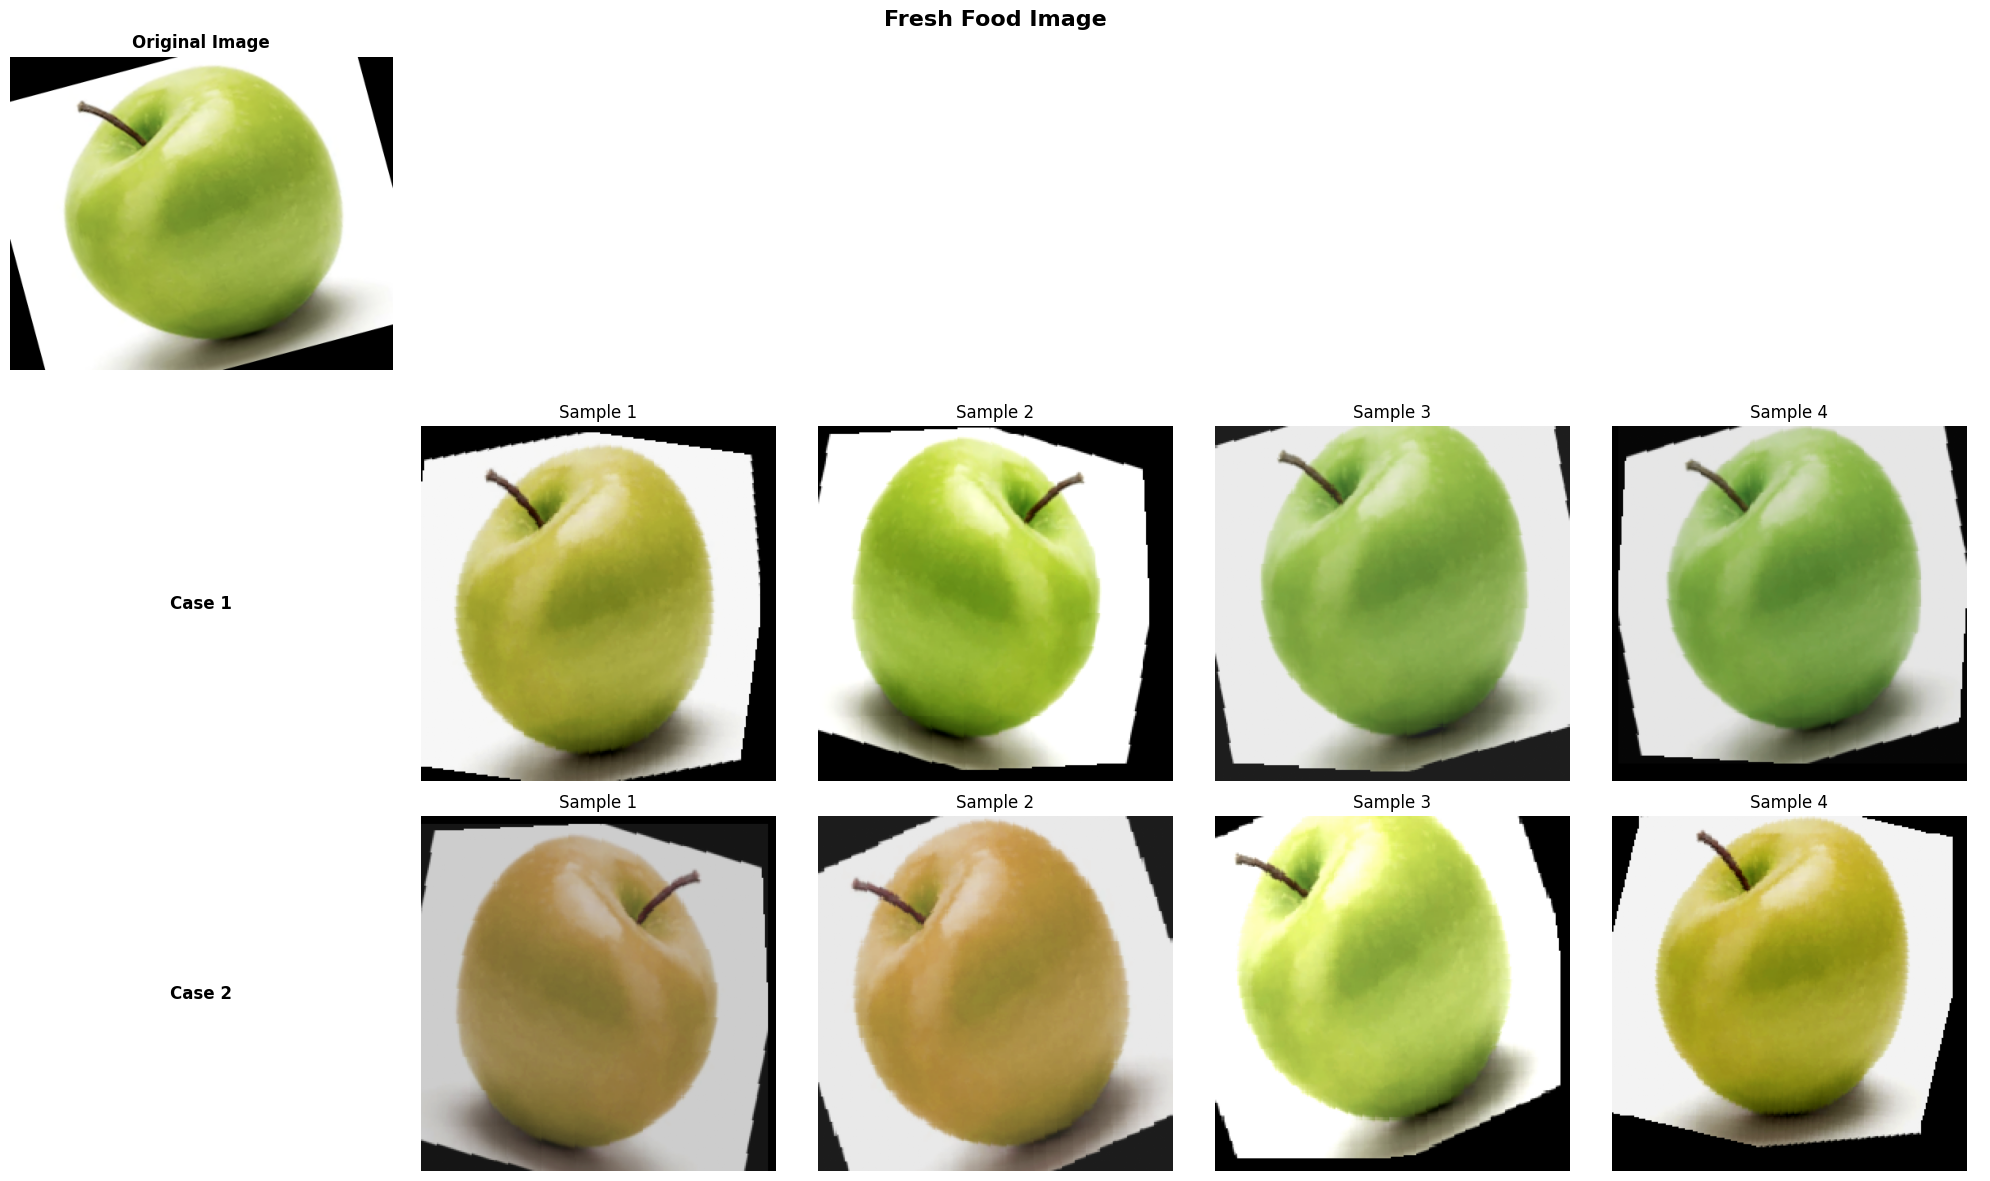

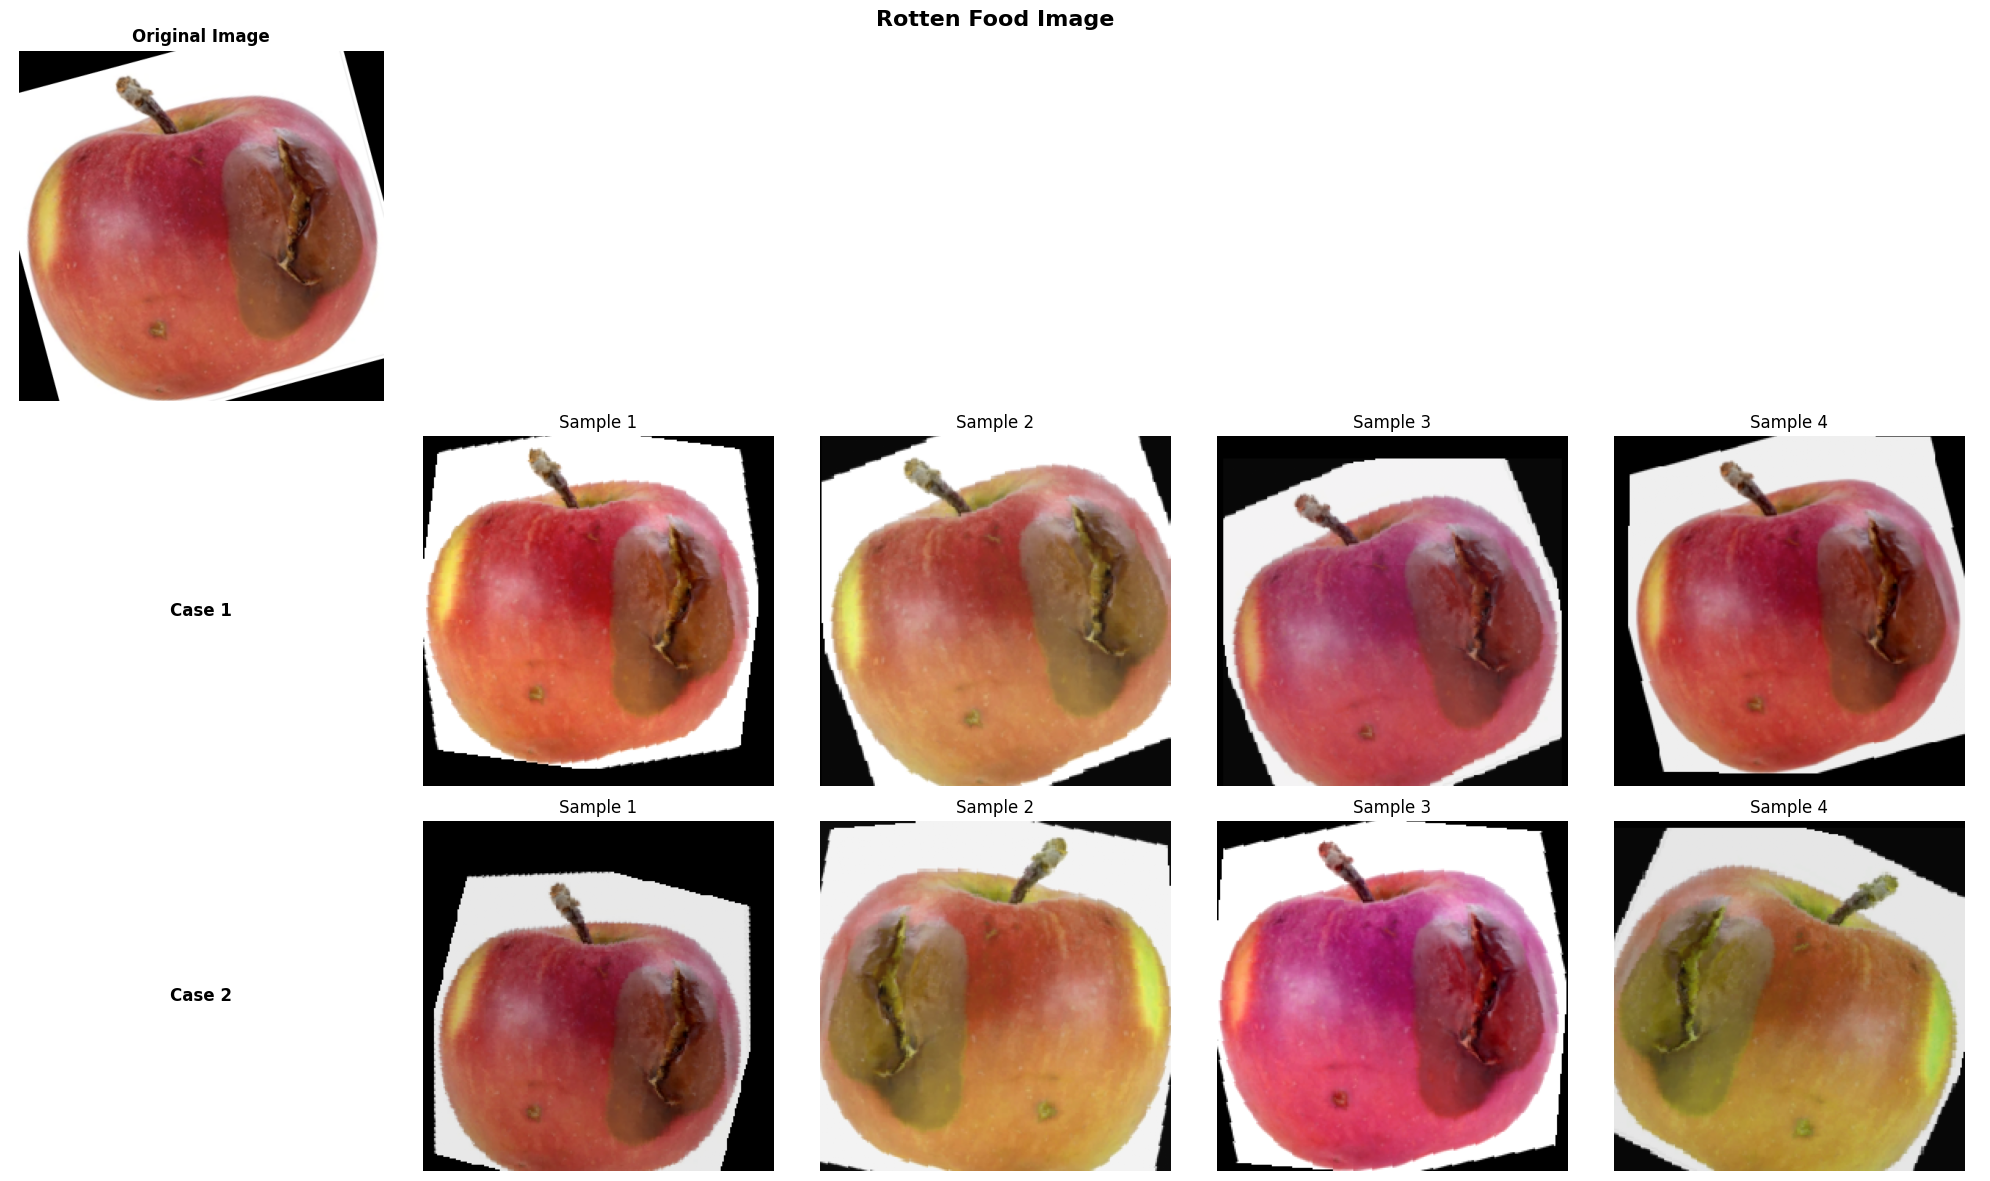

In [4]:
# 이미지 주소
sample_image_path = "./data/dataset/train/fresh/a_f001.png"
sample_image_path2 = "./data/dataset/train/rotten/a_r001.png"

#시각화 코드
# Case 1
data_transforms_case1 = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.15, saturation=0.1, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.RandomApply([
            transforms.ColorJitter(contrast=0.3)
        ], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# Case 2
data_transforms_case2 = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# 정규화
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize tensor back to original image range"""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

def apply_transforms_and_visualize(image_path, image_title):
    # 이미지 로드
    original_image = Image.open(image_path).convert('RGB')
    
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    fig.suptitle(f'{image_title}', fontsize=16, fontweight='bold')
    
    # 원본 이미지
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    for i in range(1, 5):
        axes[0, i].axis('off')
    
    # Case 1
    axes[1, 0].text(0.5, 0.5, 'Case 1', 
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    transform=axes[1, 0].transAxes)
    axes[1, 0].axis('off')
    
    for i in range(1, 5):
        # 이미지에 변형 적용
        transformed = data_transforms_case1['train'](original_image)
        denorm_img = denormalize(transformed)
        # 텐서 변환
        img_array = denorm_img.permute(1, 2, 0).numpy()
        
        axes[1, i].imshow(img_array)
        axes[1, i].set_title(f'Sample {i}')
        axes[1, i].axis('off')
    
    # Case 2
    axes[2, 0].text(0.5, 0.5, 'Case 2', 
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    transform=axes[2, 0].transAxes)
    axes[2, 0].axis('off')
    
    for i in range(1, 5):
        # 이미지에 변형 적용
        transformed = data_transforms_case2['train'](original_image)
        # Denormalize
        denorm_img = denormalize(transformed)
        # 텐서 변환
        img_array = denorm_img.permute(1, 2, 0).numpy()
        
        axes[2, i].imshow(img_array)
        axes[2, i].set_title(f'Sample {i}')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()

def show_parameter_comparison():
    # 각 전처리 방법의 파라미터 비교 테이블
    print("=" * 80)
    print("Preprocessing Parameter Comparison")
    print("=" * 80)
    
    comparison_data = [
        ("Transform Type", "Case 1 (90%)", "Case 2 (95%)", "Change"),
        ("-" * 20, "-" * 15, "-" * 15, "-" * 10),
        ("RandomHorizontalFlip", "p=0.3 (30%)", "p=0.5 (50%)", "+67%"),
        ("RandomRotation", "±10 degrees", "±15 degrees", "+50%"),
        ("ColorJitter - brightness", "0.1", "0.2", "+100%"),
        ("ColorJitter - contrast", "0.15", "0.2", "+33%"),
        ("ColorJitter - saturation", "0.1", "0.2", "+100%"),
        ("ColorJitter - hue", "0.05", "0.1", "+100%"),
        ("RandomAffine - translate", "(0.05, 0.05)", "(0.1, 0.1)", "+100%"),
        ("RandomAffine - scale", "(0.95, 1.05)", "(0.9, 1.1)", "+100%"),
        ("Additional ColorJitter", "Present", "Removed", "Simplified"),
    ]
    
    for row in comparison_data:
        print(f"{row[0]:<20} | {row[1]:<15} | {row[2]:<15} | {row[3]:<10}")

# 파라미터 출력
show_parameter_comparison()

print("\n" + "=" * 80)
print("Image Preprocessing Visualization")
print("=" * 80)

# Fresh image
try:
    apply_transforms_and_visualize(sample_image_path, "Fresh Food Image")
except FileNotFoundError:
    print(f"Fresh image not found: {sample_image_path}")

# Rotten image
try:
    apply_transforms_and_visualize(sample_image_path2, "Rotten Food Image")
except FileNotFoundError:
    print(f"Rotten image not found: {sample_image_path2}")

In [ ]:
def create_food101_loaders(base_dir, data_transforms, batch_size=64):
        """FOOD101 데이터셋 로더 생성 (음식 도메인 적응용)"""
        
        # FOOD101 디렉토리 설정
        food101_train_dir = os.path.join(base_dir, 'food101', 'train')
        food101_test_dir = os.path.join(base_dir, 'food101', 'test')
    
        food101_train_dataset = None
        food101_test_dataset = None
        
        # 위에서 전처리 데이터셋 사용
        if os.path.exists(food101_train_dir):
            food101_train_dataset = datasets.ImageFolder(
                food101_train_dir,
                transform=data_transforms['train']
            )
            
        if os.path.exists(food101_test_dir):
            food101_test_dataset = datasets.ImageFolder(
                food101_test_dir,
                transform=data_transforms['val']
            )
        
        # 데이터로더 생성
        food101_train_loader = None
        food101_test_loader = None
        
        if food101_train_dataset:
            food101_train_loader = DataLoader(
                food101_train_dataset,
                batch_size=batch_size,
                shuffle=True,
                num_workers=4,
                pin_memory=True if torch.cuda.is_available() else False
            )
            
        if food101_test_dataset:
            food101_test_loader = DataLoader(
                food101_test_dataset,
                batch_size=batch_size,
                shuffle=False,
                num_workers=4,
                pin_memory=True if torch.cuda.is_available() else False
            )
        
        # FOOD101 클래스 정보
        food101_classes = food101_train_dataset.classes if food101_train_dataset else []
        food101_num_classes = len(food101_classes)
        
        if food101_train_dataset:
            print(f"[FOOD101] 훈련 이미지: {len(food101_train_dataset)}개")
            print(f"[FOOD101] 클래스 수: {food101_num_classes}개")
        if food101_test_dataset:
            print(f"[FOOD101] 테스트 이미지: {len(food101_test_dataset)}개")

        return food101_train_loader, food101_test_loader, food101_num_classes


In [6]:
# 쿠다
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

food101_train_loader, food101_test_loader, num_classes = create_food101_loaders(base_dir='./images', data_transforms=data_transforms)

[FOOD101] 훈련 이미지: 30224개
[FOOD101] 클래스 수: 38개
[FOOD101] 테스트 이미지: 7556개


# ResNet 50 모델 선언

In [ ]:
model = models.resnet50(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, num_classes)  # FOOD101 클래스 수는 101개

model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
#  마지막 block fc 학습
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True


[FOOD101] 훈련 이미지: 30224개
[FOOD101] 클래스 수: 38개
[FOOD101] 테스트 이미지: 7556개


/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [70]:
# 손실함수, 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001) # Optimizer 사용에 있어 학습가능한 수정하는 부분만 옵티마이저 적용

In [71]:
# 훈련 및 검증 루프 설정
best_val_acc = 0.0
patience = 3
patience_counter = 0

# FOOD101 사전 학습 진행
num_epochs = 15

# ====== 훈련 단계 ======
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(food101_train_loader, desc=f"[Train Epoch {epoch+1}/{num_epochs}]")

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=correct / total)

    train_loss = running_loss / total
    train_acc = correct / total
    

[Train Epoch 15/15]: 100%|██████████| 473/473 [00:40<00:00, 11.65it/s, acc=0.962, loss=0.286] 


## CASE1: Conv Layer 4도 학습

In [72]:
# FOOD 데이터 학습한 모델을 2진 분류로 변경 
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device) 
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

## CASE2: FC 레이어만 수정

In [73]:
# FOOD 데이터 학습한 모델을 2진 분류로 변경
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.parameters():
    param.requires_grad = False 
for param in model.fc.parameters():
    param.requires_grad = True

model2 = model.to(device) 
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.0001)

In [ ]:
# 모델 학습
num_epochs = 10 
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    print(f"\n[Epoch {epoch+1}/{num_epochs}]")
    train_loop = tqdm(train_loader, desc="Training", leave=True)

    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(loss=loss.item(), acc=correct / total)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
   

    print(f"Train Loss: {epoch_loss:.4f}  |  Train Accuracy: {epoch_acc:.4f}")
    model.eval()

    # 검증 Validation
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_loop = tqdm(val_loader, desc="Validation", leave=True)

    with torch.no_grad():
        for val_inputs, val_labels in val_loop:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item() * val_inputs.size(0)
            val_correct += (val_outputs.argmax(1) == val_labels).sum().item()
            val_total += val_labels.size(0)

            val_loop.set_postfix(loss=loss.item(), acc=val_correct / val_total)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
   

    print(f"Val Loss: {val_epoch_loss:.4f}  |  Val Accuracy: {val_epoch_acc:.4f}")

    # 베스트 모델 저장
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), "models/best_model.pth")
        print(f"Best model saved at epoch {epoch+1}")


[Epoch 1/10]


Training:   0%|          | 0/444 [00:00<?, ?it/s]

Training: 100%|██████████| 444/444 [03:24<00:00,  2.17it/s, acc=0.948, loss=0.131] 


Train Loss: 0.1316  |  Train Accuracy: 0.9479


Validation: 100%|██████████| 111/111 [00:34<00:00,  3.22it/s, acc=0.982, loss=0.0433]


...

Val Loss: 0.0223  |  Val Accuracy: 0.9927
Best model saved at epoch 9

[Epoch 10/10]


Training: 100%|██████████| 444/444 [03:20<00:00,  2.21it/s, acc=0.994, loss=0.00752] 


Train Loss: 0.0178  |  Train Accuracy: 0.9942


Validation: 100%|██████████| 111/111 [00:31<00:00,  3.58it/s, acc=0.991, loss=0.00881] 

Val Loss: 0.0282  |  Val Accuracy: 0.9913


In [74]:
# 모델 학습 (FC 레이어만 학습)
num_epochs = 10

best_val_acc = 0.0

for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    print(f"\n[Epoch {epoch+1}/{num_epochs}]")
    train_loop = tqdm(train_loader, desc="Training", leave=True)
    
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
        
        train_loop.set_postfix(loss=loss.item(), acc=correct / total)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
        
    print(f"Train Loss: {epoch_loss:.4f}  |  Train Accuracy: {epoch_acc:.4f}")
    
    model2.eval()
    
    # 검증 Validation
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    val_loop = tqdm(val_loader, desc="Validation", leave=True)
    
    with torch.no_grad():
        for val_inputs, val_labels in val_loop:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model2(val_inputs)
            loss = criterion(val_outputs, val_labels)
            
            val_loss += loss.item() * val_inputs.size(0)
            val_correct += (val_outputs.argmax(1) == val_labels).sum().item()
            val_total += val_labels.size(0)
            
            val_loop.set_postfix(loss=loss.item(), acc=val_correct / val_total)
    
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
        
    print(f"Val Loss: {val_epoch_loss:.4f}  |  Val Accuracy: {val_epoch_acc:.4f}")
    
    # 베스트 모델 저장
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model2.state_dict(), "models/best_transfer_model2.pth")
        print(f"Best model2 saved at epoch {epoch+1}")

print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.4f}")


[Epoch 1/10]


Training: 100%|██████████| 444/444 [03:09<00:00,  2.35it/s, acc=0.785, loss=0.238]


Train Loss: 0.4750  |  Train Accuracy: 0.7852


Validation: 100%|██████████| 111/111 [00:31<00:00,  3.47it/s, acc=0.816, loss=0.507]


Val Loss: 0.4202  |  Val Accuracy: 0.8158
Best model2 saved at epoch 1

[Epoch 2/10]


...

Val Loss: 0.2916  |  Val Accuracy: 0.8797
Best model2 saved at epoch 9

[Epoch 10/10]


Training: 100%|██████████| 444/444 [03:06<00:00,  2.38it/s, acc=0.876, loss=0.173]


Train Loss: 0.3063  |  Train Accuracy: 0.8759


Validation: 100%|██████████| 111/111 [00:31<00:00,  3.56it/s, acc=0.887, loss=0.284]


Val Loss: 0.2863  |  Val Accuracy: 0.8867
Best model2 saved at epoch 10

Training completed! Best validation accuracy: 0.8867


In [75]:
# 모델 불러오기
model.load_state_dict(torch.load("models/best_transfer_model2.pth"))
model = model.to(device)
model.eval()

/tmp/ipykernel_421093/1681767857.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best_transfer_model2.pth"))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# 모델 불러오기
model.load_state_dict(torch.load("models/best_model.pth"))
model = model.to(device)
model.eval()

In [76]:
# 모델 불러오기(FC 레이어만 학습)
model.load_state_dict(torch.load("models/best_transfer_model2.pth"))
model2 = model.to(device)
model2.eval()

/tmp/ipykernel_421093/1645655535.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best_transfer_model2.pth"))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# 테스트 평가
test_loss = 0.0
test_correct = 0
test_total = 0

criterion = nn.CrossEntropyLoss()
test_loop = tqdm(test_loader, desc="Testing")

with torch.no_grad():
    for inputs, labels in test_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()
        test_total += labels.size(0)

        test_loop.set_postfix(loss=loss.item(), acc=test_correct / test_total)

# 결과 출력
final_loss = test_loss / test_total
final_acc = test_correct / test_total

print(f"\n [최종 테스트 결과]")
print(f"Test Loss: {final_loss:.4f}")
print(f"Test Accuracy: {final_acc:.4f}")

/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


/tmp/ipykernel_411466/2888833430.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best_model.pth"))
Testing:  18%|█▊        | 68/


 [최종 테스트 결과]
Test Loss: 0.1978
Test Accuracy: 0.9582


In [77]:
# 테스트 평가 (Model2 - FC 레이어만 학습한 모델)
test_loss = 0.0
test_correct = 0
test_total = 0

criterion = nn.CrossEntropyLoss()
test_loop = tqdm(test_loader, desc="Testing Transfer Model")

with torch.no_grad():
    for inputs, labels in test_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model2(inputs)  # model2 사용
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()
        test_total += labels.size(0)

        test_loop.set_postfix(loss=loss.item(), acc=test_correct / test_total)

# 결과 출력
final_loss = test_loss / test_total
final_acc = test_correct / test_total

print(f"\n [FC Layer fine_tuining 모델 최종 테스트 결과]")
print(f"Test Loss: {final_loss:.4f}")
print(f"Test Accuracy: {final_acc:.4f}")

Testing Transfer Model:  18%|█▊        | 68/379 [00:36<01:36,  3.21it/s, acc=0.831, loss=1.4]   /home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing Transfer Model: 100%|██████████| 379/379 [02:13<00:00,  2.84it/s, acc=0.879, loss=0.0642]


 [FC Layer fine_tuining 모델 최종 테스트 결과]
Test Loss: 0.2914
Test Accuracy: 0.8793


/tmp/ipykernel_411466/3985202079.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best_model.pth"))
Testing: 100%|██████████| 37


Detailed Model Evaluation Results
Overall Performance:
   - Accuracy:  0.9582
   - Precision: 0.9666
   - Recall:    0.9587
   - F1 Score:  0.9626
   - Test Loss: 0.1978

Per-class Performance:
   - Normal - Precision: 0.9477, Recall: 0.9576, F1: 0.9527
   - Rotten - Precision: 0.9666, Recall: 0.9587, F1: 0.9626

ROC & PR Performance:
   - ROC AUC: 0.9907
   - Average Precision: 0.9921
\Classification result:
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95     10621
      Rotten       0.97      0.96      0.96     13583

    accuracy                           0.96     24204
   macro avg       0.96      0.96      0.96     24204
weighted avg       0.96      0.96      0.96     24204



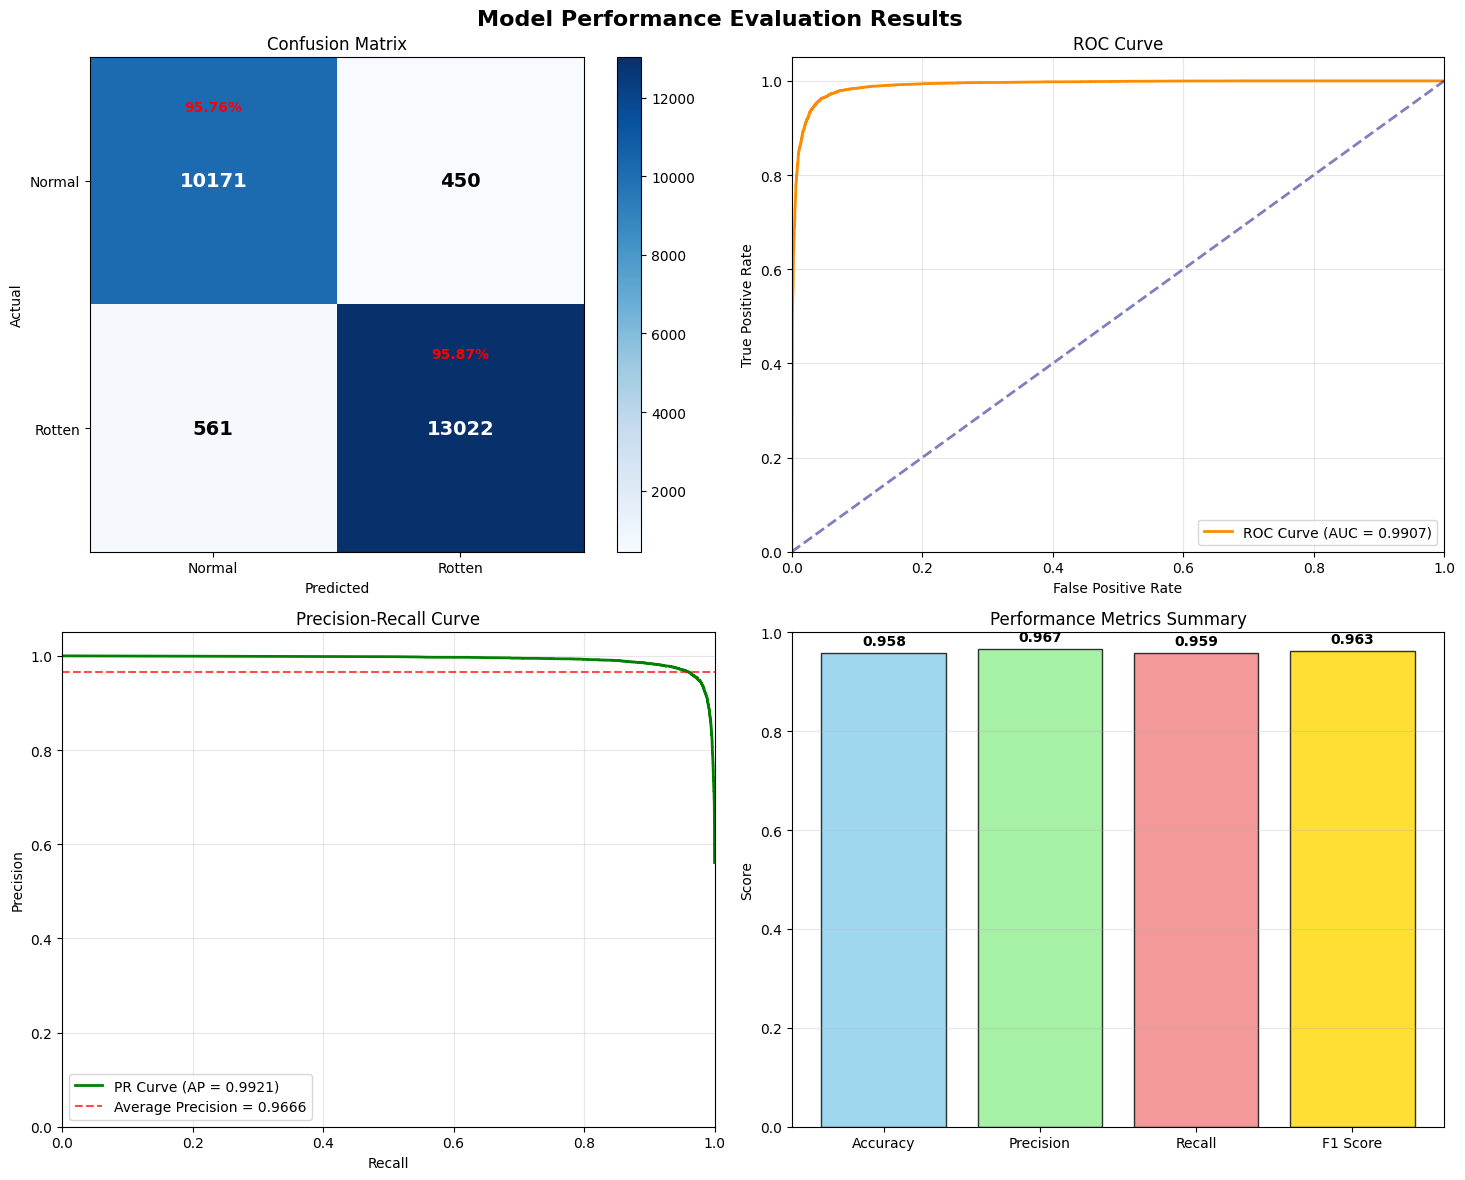


Threshold-based Performance Analysis:
--------------------------------------------------
Threshold  Precision  Recall     F1        
--------------------------------------------------
0.3        0.9596     0.9664     0.9630    
0.4        0.9639     0.9625     0.9632    
0.5        0.9666     0.9587     0.9626    
0.6        0.9688     0.9551     0.9619    
0.7        0.9711     0.9500     0.9604    

Misclassification Analysis:
----------------------------------------
False Positive (Normal->Rotten misclassification): 450 cases
False Negative (Rotten->Normal misclassification): 561 cases


In [ ]:
# confusion matrix 시각화
def plot_confusion_matrix(cm, class_names, ax):
    """
    matplotlib을 사용해 혼동 행렬 히트맵 그리기
    """
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')
    
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    return ax

# 모델 불러오기
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)  # 이진 분류
model.load_state_dict(torch.load("models/best_model.pth"))
model = model.to(device)
model.eval()

# 결과 분석
def detailed_evaluation(model, test_loader, device):
    model.eval()
    
    # 결과 저장을 위한 리스트
    all_predictions = []
    all_labels = []
    all_probabilities = []
    test_loss = 0.0
    
    criterion = nn.CrossEntropyLoss()
    test_loop = tqdm(test_loader, desc="Testing")
    
    with torch.no_grad():
        for inputs, labels in test_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 확률 계산 - sofmax
            probabilities = F.softmax(outputs, dim=1)
            
            # 예측값
            predictions = outputs.argmax(1)
            
            # 결과 저장
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            test_loss += loss.item() * inputs.size(0)
            test_loop.set_postfix(loss=loss.item())
    
    # numpy 배열로 변환
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    return all_predictions, all_labels, all_probabilities, test_loss / len(all_labels)

# 평가 실행
predictions, true_labels, probabilities, avg_loss = detailed_evaluation(model, test_loader, device)

# 1. 기본 성능 지표 계산
accuracy = (predictions == true_labels).mean()
precision = precision_score(true_labels, predictions, average='binary')
recall = recall_score(true_labels, predictions, average='binary')
f1 = f1_score(true_labels, predictions, average='binary')

# 2. 클래스별 성능 지표
precision_per_class = precision_score(true_labels, predictions, average=None)
recall_per_class = recall_score(true_labels, predictions, average=None)
f1_per_class = f1_score(true_labels, predictions, average=None)

# 3. ROC 커브를 위한 데이터 준비
# 클래스 1 (썩음)에 대한 확률 사용
rotten_probabilities = probabilities[:, 1]
fpr, tpr, thresholds = roc_curve(true_labels, rotten_probabilities)
roc_auc = auc(fpr, tpr)

# 4. Precision-Recall 커브
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(true_labels, rotten_probabilities)
avg_precision = average_precision_score(true_labels, rotten_probabilities)

# 5. 혼동 행렬
cm = confusion_matrix(true_labels, predictions)

# 결과 출력
print("\n" + "="*60)
print("Detailed Model Evaluation Results")
print("="*60)

print(f"Overall Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1 Score:  {f1:.4f}")
print(f"   - Test Loss: {avg_loss:.4f}")

print(f"\nPer-class Performance:")
class_names = ['Normal', 'Rotten']
for i, class_name in enumerate(class_names):
    print(f"   - {class_name:6s} - Precision: {precision_per_class[i]:.4f}, "
          f"Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")

print(f"\nROC & PR Performance:")
print(f"   - ROC AUC: {roc_auc:.4f}")
print(f"   - Average Precision: {avg_precision:.4f}")

# 6. 상세한 분류 리포트
print(f"\Classification result:")
print(classification_report(true_labels, predictions, target_names=class_names))

# 7. 시각화
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Evaluation Results', fontsize=16, fontweight='bold')

# 7-1. 혼동 행렬
ax1 = axes[0, 0]
plot_confusion_matrix(cm, class_names, ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 정확도 정보 추가
for i in range(2):
    for j in range(2):
        if i == j:
            ax1.text(j, i-0.3, f'{cm[i,j]/cm[i,:].sum():.2%}', 
                    ha='center', va='center', color='red', fontweight='bold')

# 7-2. ROC 커브
ax2 = axes[0, 1]
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 7-3. Precision-Recall 커브
ax3 = axes[1, 0]
ax3.plot(recall_curve, precision_curve, color='green', lw=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
ax3.axhline(y=precision, color='red', linestyle='--', alpha=0.7, 
           label=f'Average Precision = {precision:.4f}')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 7-4. 성능 지표 바 차트
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = ax4.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylim([0, 1])
ax4.set_ylabel('Score')
ax4.set_title('Performance Metrics Summary')
ax4.grid(True, alpha=0.3, axis='y')

# 바 위에 값 표시
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 8. 임계값별 성능 분석
print(f"\nThreshold-based Performance Analysis:")
print("-" * 50)
print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 50)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_thresh = (rotten_probabilities > threshold).astype(int)
    prec_thresh = precision_score(true_labels, pred_thresh)
    rec_thresh = recall_score(true_labels, pred_thresh)
    f1_thresh = f1_score(true_labels, pred_thresh)
    
    print(f"{threshold:<10.1f} {prec_thresh:<10.4f} {rec_thresh:<10.4f} {f1_thresh:<10.4f}")

# 9. 오분류 샘플 분석
print(f"\nMisclassification Analysis:")
print("-" * 40)

# False Positive (정상을 썩음으로 잘못 분류)
fp_indices = np.where((true_labels == 0) & (predictions == 1))[0]
# False Negative (썩음을 정상으로 잘못 분류)  
fn_indices = np.where((true_labels == 1) & (predictions == 0))[0]

print(f"False Positive (Normal->Rotten misclassification): {len(fp_indices)} cases")
print(f"False Negative (Rotten->Normal misclassification): {len(fn_indices)} cases")

/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_421093/1132471329.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only`


Detailed Model Evaluation Results
Overall Performance:
   - Accuracy:  0.8793
   - Precision: 0.8986
   - Recall:    0.8847
   - F1 Score:  0.8916
   - Test Loss: 0.2914

Per-class Performance:
   - Normal - Precision: 0.8554, Recall: 0.8723, F1: 0.8638
   - Rotten - Precision: 0.8986, Recall: 0.8847, F1: 0.8916

ROC & PR Performance:
   - ROC AUC: 0.9482
   - Average Precision: 0.9571
\Classification result:
              precision    recall  f1-score   support

      Normal       0.86      0.87      0.86     10621
      Rotten       0.90      0.88      0.89     13583

    accuracy                           0.88     24204
   macro avg       0.88      0.88      0.88     24204
weighted avg       0.88      0.88      0.88     24204



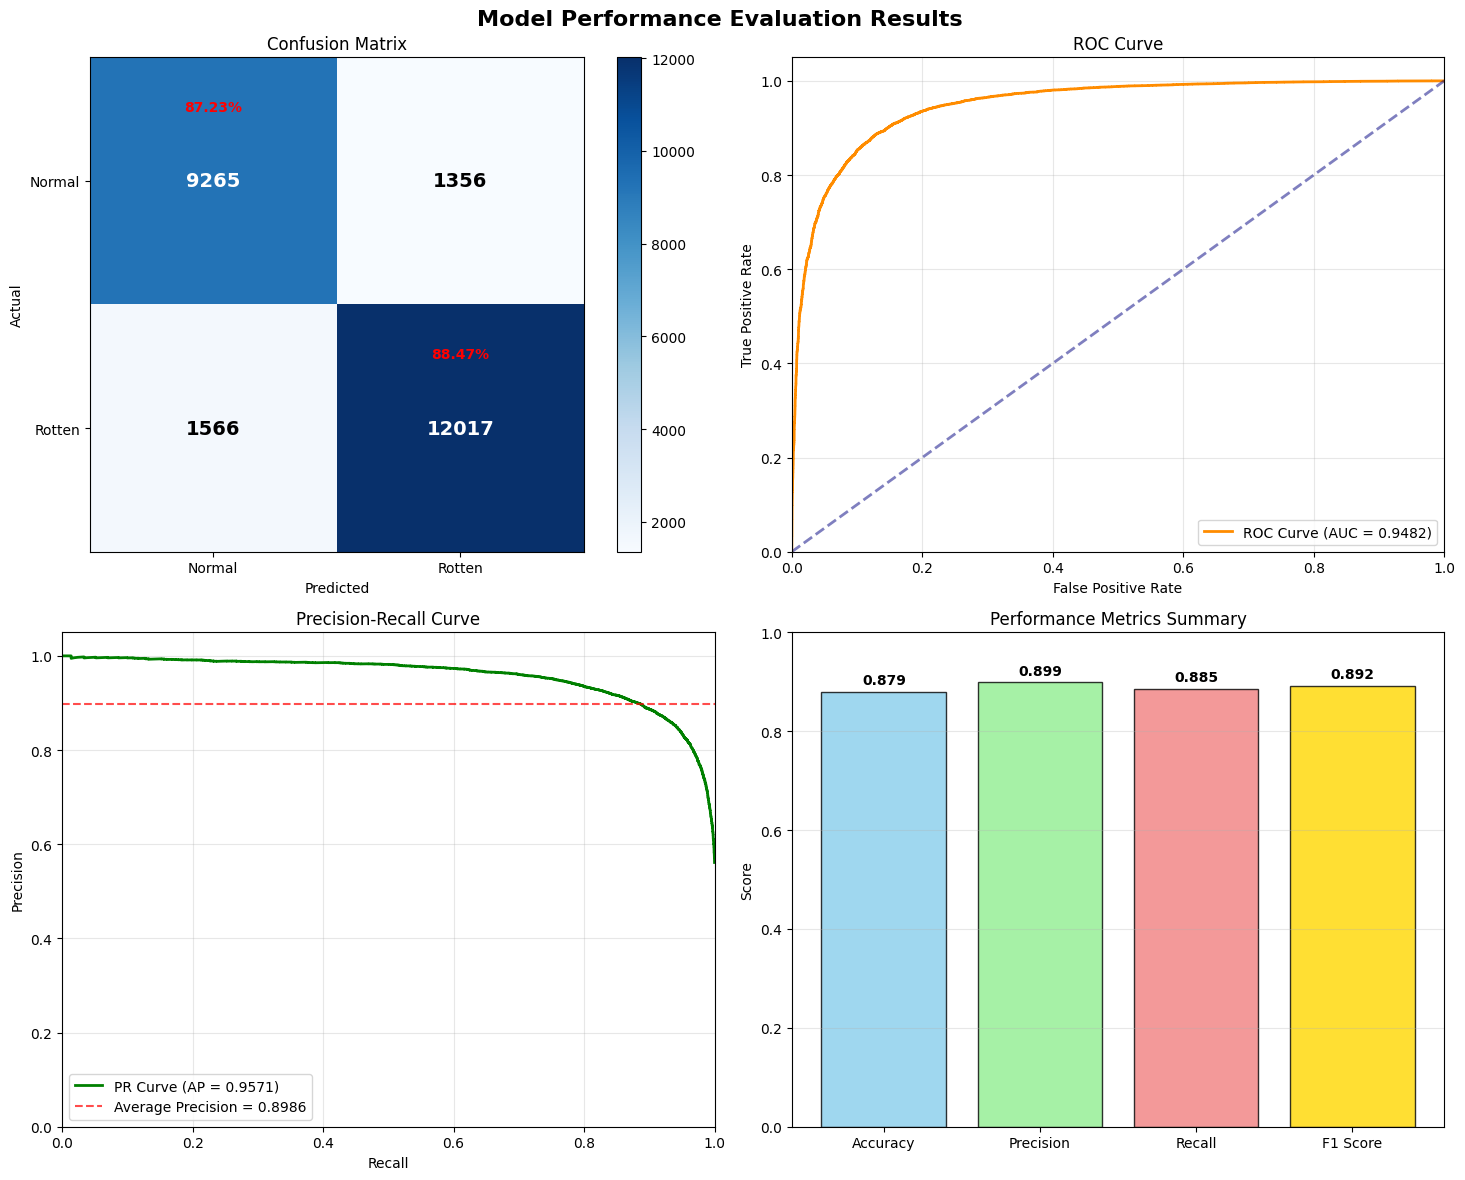


Threshold-based Performance Analysis:
--------------------------------------------------
Threshold  Precision  Recall     F1        
--------------------------------------------------
0.3        0.8431     0.9460     0.8916    
0.4        0.8739     0.9170     0.8949    
0.5        0.8986     0.8847     0.8916    
0.6        0.9194     0.8417     0.8789    
0.7        0.9392     0.7903     0.8583    

Misclassification Analysis:
----------------------------------------
False Positive (Normal->Rotten misclassification): 1356 cases
False Negative (Rotten->Normal misclassification): 1566 cases


In [ ]:
# confusion matrix 시각화
def plot_confusion_matrix(cm, class_names, ax):
    """
    matplotlib을 사용해 혼동 행렬 히트맵 그리기
    """
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')
    
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    return ax

# 모델 불러오기
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)  # 이진 분류
model.load_state_dict(torch.load("models/best_transfer_model2.pth"))
model = model.to(device)
model.eval()

# 결과 분석
def detailed_evaluation(model, test_loader, device):
    model.eval()
    
    # 결과 저장을 위한 리스트
    all_predictions = []
    all_labels = []
    all_probabilities = []
    test_loss = 0.0
    
    criterion = nn.CrossEntropyLoss()
    test_loop = tqdm(test_loader, desc="Testing")
    
    with torch.no_grad():
        for inputs, labels in test_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 확률 계산 - sofmax
            probabilities = F.softmax(outputs, dim=1)
            
            # 예측값
            predictions = outputs.argmax(1)
            
            # 결과 저장
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            test_loss += loss.item() * inputs.size(0)
            test_loop.set_postfix(loss=loss.item())
    
    # numpy 배열로 변환
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    return all_predictions, all_labels, all_probabilities, test_loss / len(all_labels)

# 평가 실행
predictions, true_labels, probabilities, avg_loss = detailed_evaluation(model, test_loader, device)

# 1. 기본 성능 지표 계산
accuracy = (predictions == true_labels).mean()
precision = precision_score(true_labels, predictions, average='binary')
recall = recall_score(true_labels, predictions, average='binary')
f1 = f1_score(true_labels, predictions, average='binary')

# 2. 클래스별 성능 지표
precision_per_class = precision_score(true_labels, predictions, average=None)
recall_per_class = recall_score(true_labels, predictions, average=None)
f1_per_class = f1_score(true_labels, predictions, average=None)

# 3. ROC 커브를 위한 데이터 준비
# 클래스 1 (썩음)에 대한 확률 사용
rotten_probabilities = probabilities[:, 1]
fpr, tpr, thresholds = roc_curve(true_labels, rotten_probabilities)
roc_auc = auc(fpr, tpr)

# 4. Precision-Recall 커브
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(true_labels, rotten_probabilities)
avg_precision = average_precision_score(true_labels, rotten_probabilities)

# 5. 혼동 행렬
cm = confusion_matrix(true_labels, predictions)

# 결과 출력
print("\n" + "="*60)
print("Detailed Model Evaluation Results")
print("="*60)

print(f"Overall Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1 Score:  {f1:.4f}")
print(f"   - Test Loss: {avg_loss:.4f}")

print(f"\nPer-class Performance:")
class_names = ['Normal', 'Rotten']
for i, class_name in enumerate(class_names):
    print(f"   - {class_name:6s} - Precision: {precision_per_class[i]:.4f}, "
          f"Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")

print(f"\nROC & PR Performance:")
print(f"   - ROC AUC: {roc_auc:.4f}")
print(f"   - Average Precision: {avg_precision:.4f}")

# 6. 상세한 분류 리포트
print(f"\Classification result:")
print(classification_report(true_labels, predictions, target_names=class_names))

# 7. 시각화
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Evaluation Results', fontsize=16, fontweight='bold')

# 7-1. 혼동 행렬
ax1 = axes[0, 0]
plot_confusion_matrix(cm, class_names, ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 정확도 정보 추가
for i in range(2):
    for j in range(2):
        if i == j:
            ax1.text(j, i-0.3, f'{cm[i,j]/cm[i,:].sum():.2%}', 
                    ha='center', va='center', color='red', fontweight='bold')

# 7-2. ROC 커브
ax2 = axes[0, 1]
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 7-3. Precision-Recall 커브
ax3 = axes[1, 0]
ax3.plot(recall_curve, precision_curve, color='green', lw=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
ax3.axhline(y=precision, color='red', linestyle='--', alpha=0.7, 
           label=f'Average Precision = {precision:.4f}')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 7-4. 성능 지표 바 차트
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = ax4.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylim([0, 1])
ax4.set_ylabel('Score')
ax4.set_title('Performance Metrics Summary')
ax4.grid(True, alpha=0.3, axis='y')

# 바 위에 값 표시
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 8. 임계값별 성능 분석
print(f"\nThreshold-based Performance Analysis:")
print("-" * 50)
print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 50)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_thresh = (rotten_probabilities > threshold).astype(int)
    prec_thresh = precision_score(true_labels, pred_thresh)
    rec_thresh = recall_score(true_labels, pred_thresh)
    f1_thresh = f1_score(true_labels, pred_thresh)
    
    print(f"{threshold:<10.1f} {prec_thresh:<10.4f} {rec_thresh:<10.4f} {f1_thresh:<10.4f}")

# 9. 오분류 샘플 분석
print(f"\nMisclassification Analysis:")
print("-" * 40)

# False Positive (정상을 썩음으로 잘못 분류)
fp_indices = np.where((true_labels == 0) & (predictions == 1))[0]
# False Negative (썩음을 정상으로 잘못 분류)  
fn_indices = np.where((true_labels == 1) & (predictions == 0))[0]

print(f"False Positive (Normal->Rotten misclassification): {len(fp_indices)} cases")
print(f"False Negative (Rotten->Normal misclassification): {len(fn_indices)} cases")

In [10]:
# Grad-CAM 시각화

# -----------------------
# 1. 이미지 전처리 함수
# -----------------------
def preprocess_image(img_path):
    raw_image = Image.open(img_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return preprocess(raw_image).unsqueeze(0), raw_image

# -----------------------
# 2. Grad-CAM 클래스
# -----------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        pooled_grad = torch.mean(self.gradients, dim=[0, 2, 3])
        activation = self.activations[0]

        for i in range(activation.shape[0]):
            activation[i] *= pooled_grad[i]

        heatmap = activation.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap)
        return heatmap

/tmp/ipykernel_421093/3314831325.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/best_model.pth', map_location=device))
/home/ha


=== Rotten Food 분석 ===
예측 결과: Rotten
신뢰도: 99.99%
  Fresh: 0.01%
  Rotten: 99.99%


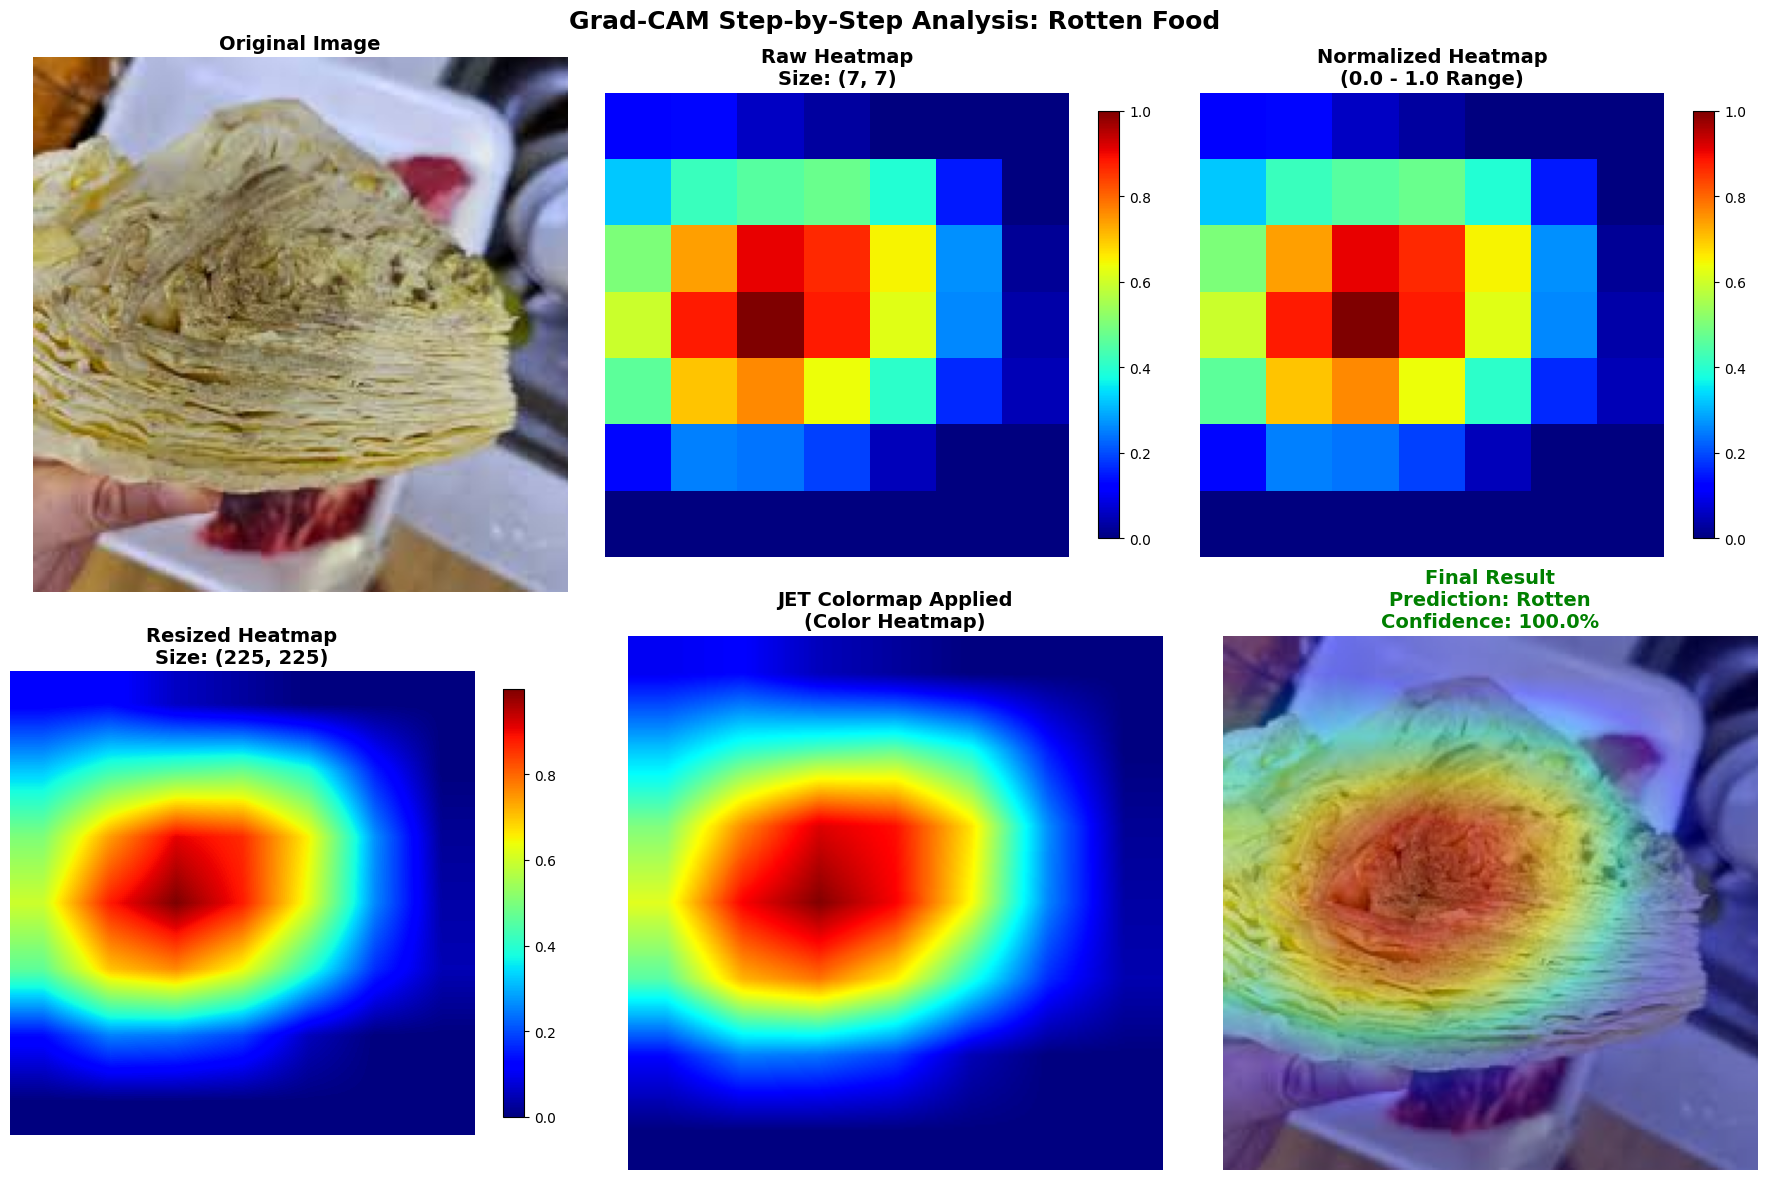


=== Fresh Food 분석 ===
예측 결과: Fresh
신뢰도: 99.88%
  Fresh: 99.88%
  Rotten: 0.12%


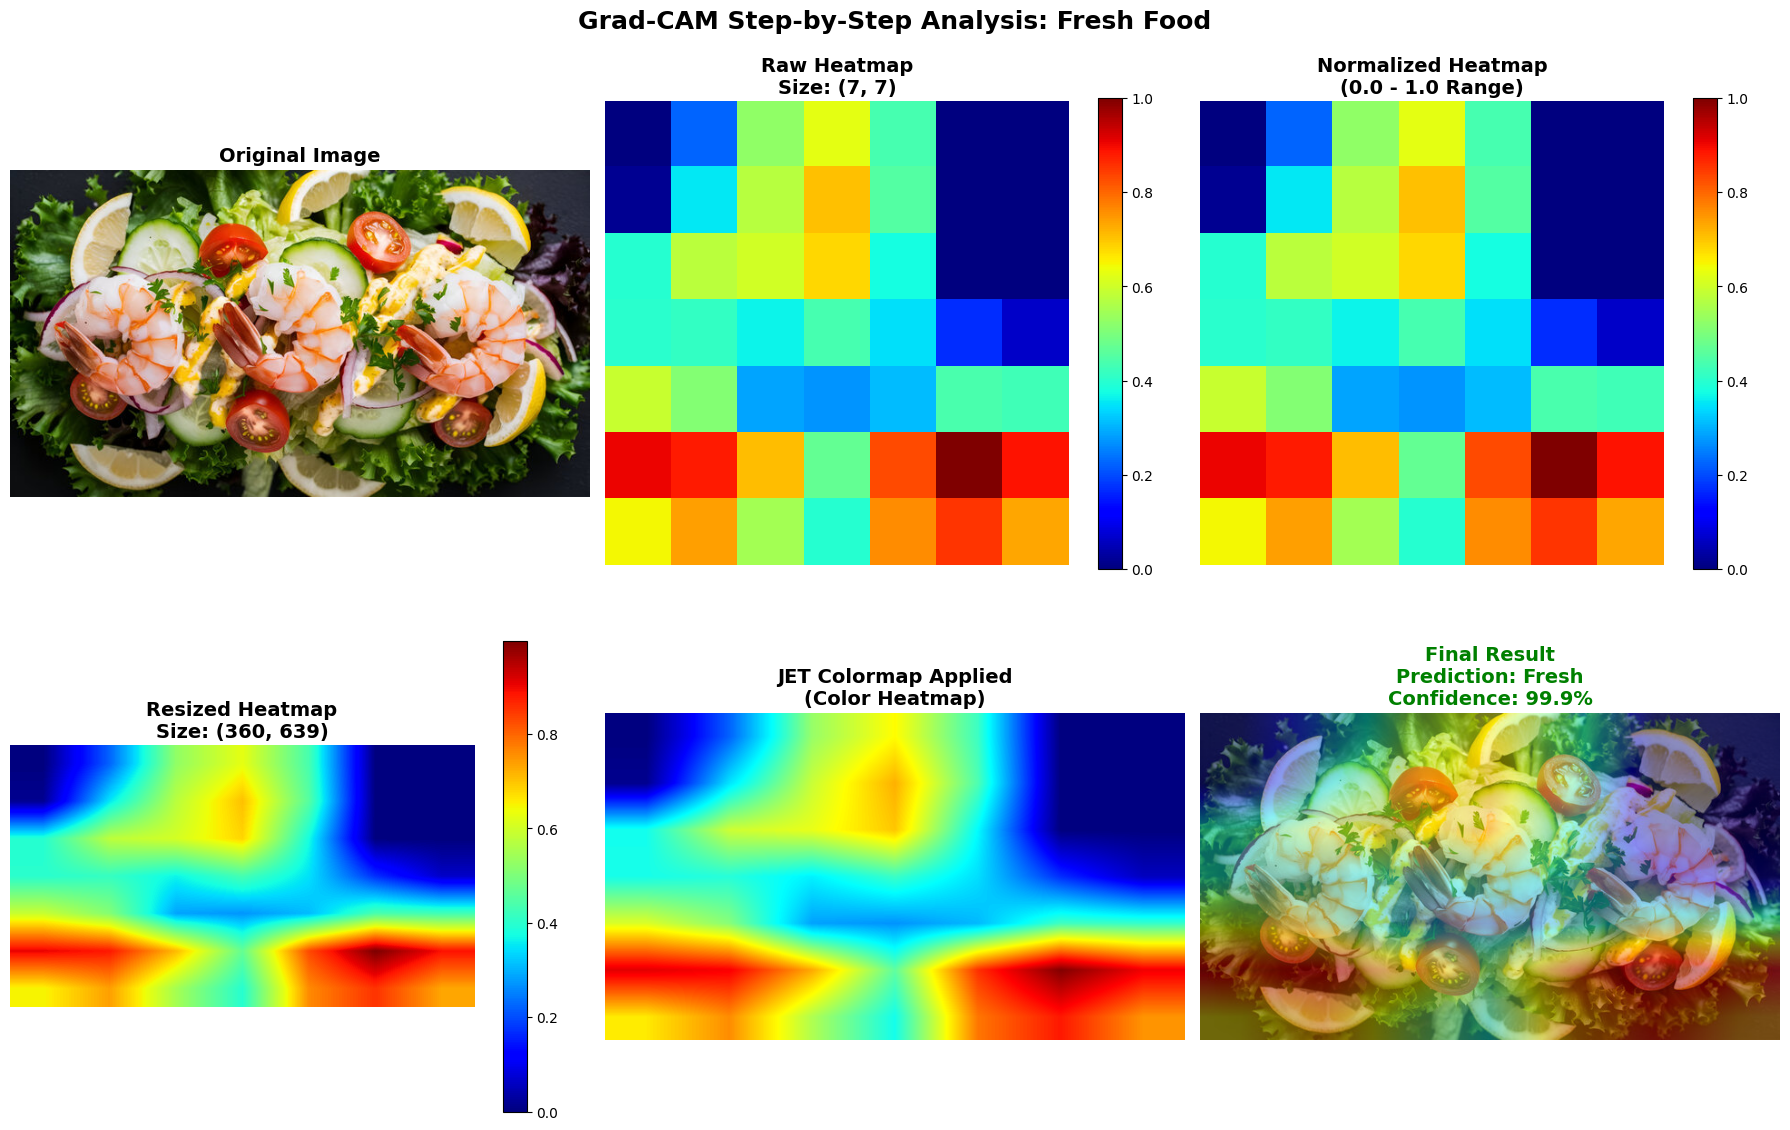

In [82]:
# -----------------------
# 3. Grad-CAM 적용 및 예측
# -----------------------
# 학습된 모델 불러오기
model.load_state_dict(torch.load('models/best_model.pth', map_location=device))
model.eval()

# 클래스 이름 정의
class_names = ['Fresh', 'Rotten']

# 사용할 레이어
target_layer = model.layer4[-1]  # ResNet의 마지막 Conv 블록

grad_cam = GradCAM(model, target_layer)

# 예측 함수 정의
def predict_image(model, input_tensor, class_names):
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
        predicted_class = class_names[predicted.item()]
        confidence_score = confidence.item() * 100
        
        return predicted_class, confidence_score, probabilities[0]

# 3x2 그리드로 Grad-CAM 시각화 함수
def visualize_gradcam_grid(img_path, img_title, model, grad_cam, class_names, device):
    """
    Grad-CAM의 각 단계를 3x2 그리드로 시각화
    """
    print(f"\n=== {img_title} 분석 ===")
    
    # 이미지 전처리 및 예측
    input_tensor, raw_image = preprocess_image(img_path)
    input_tensor = input_tensor.to(device)
    predicted_class, confidence, all_probs = predict_image(model, input_tensor, class_names)
    
    # 결과 출력
    print(f"예측 결과: {predicted_class}")
    print(f"신뢰도: {confidence:.2f}%")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {all_probs[i].item()*100:.2f}%")
    
    # Grad-CAM 생성 및 각 단계별 처리
    heatmap = grad_cam.generate(input_tensor)
    
    # 각 단계별 데이터 준비
    original_image = raw_image  # 원본 이미지
    raw_heatmap = heatmap.copy()  # 모델에서 나온 원시 히트맵
    normalized_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())  # 정규화
    resized_heatmap = cv2.resize(normalized_heatmap, (raw_image.size[0], raw_image.size[1]))  # 리사이즈
    heatmap_uint8 = np.uint8(255 * resized_heatmap)  # 255 스케일 변환
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)  # JET 컬러맵 적용
    raw_image_cv = cv2.cvtColor(np.array(raw_image), cv2.COLOR_RGB2BGR)  # BGR 변환
    final_overlay = cv2.addWeighted(raw_image_cv, 0.6, heatmap_colored, 0.4, 0)  # 최종 오버레이
    
    # 3x2 그리드 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # (1,1) 원본 이미지
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # (1,2) 원시 히트맵
    im1 = axes[0, 1].imshow(raw_heatmap, cmap='jet')
    axes[0, 1].set_title(f'Raw Heatmap\nSize: {raw_heatmap.shape}', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)
    
    # (1,3) 정규화된 히트맵
    im2 = axes[0, 2].imshow(normalized_heatmap, cmap='jet')
    axes[0, 2].set_title('Normalized Heatmap\n(0.0 - 1.0 Range)', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)
    
    # (2,1) 리사이즈된 히트맵
    im3 = axes[1, 0].imshow(resized_heatmap, cmap='jet')
    axes[1, 0].set_title(f'Resized Heatmap\nSize: {resized_heatmap.shape}', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)
    
    # (2,2) 컬러맵 적용
    axes[1, 1].imshow(cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('JET Colormap Applied\n(Color Heatmap)', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    # (2,3) 최종 결과
    axes[1, 2].imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
    color = 'green' if confidence > 80 else 'orange' if confidence > 60 else 'red'
    axes[1, 2].set_title(f'Final Result\nPrediction: {predicted_class}\nConfidence: {confidence:.1f}%', 
                         fontsize=14, fontweight='bold', color=color)
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Grad-CAM Step-by-Step Analysis: {img_title}', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 테스트 이미지들에 대해 3x2 그리드 분석 실행
test_images = [
    ('RottenFood2.jpg', 'Rotten Food'),
    ('FreshFood2.jpg', 'Fresh Food')
]

for img_path, img_title in test_images:
    visualize_gradcam_grid(img_path, img_title, model, grad_cam, class_names, device)

In [ ]:
# VGG16 
model = models.vgg16(pretrained=True)

# 기존 classifier 출력층을 이진 분류로 교체
model.classifier[6] = nn.Linear(in_features=4096, out_features=2)

# 모든 파라미터 동결 
for param in model.parameters():
    param.requires_grad = False

# 마지막 fc 층만 학습 가능하도록 설정
for param in model.classifier[6].parameters():
    param.requires_grad = True

model3 = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model3.classifier[6].parameters(), lr=0.0001)

/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
num_epochs = 10

best_val_acc = 0.0

for epoch in range(num_epochs):
    model3.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    print(f"\n[Epoch {epoch+1}/{num_epochs}]")
    train_loop = tqdm(train_loader, desc="Training", leave=True)
    
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model3(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
        
        train_loop.set_postfix(loss=loss.item(), acc=correct / total)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
        
    print(f"Train Loss: {epoch_loss:.4f}  |  Train Accuracy: {epoch_acc:.4f}")
    
    model3.eval()
    
    # 검증 Validation
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    val_loop = tqdm(val_loader, desc="Validation", leave=True)
    
    with torch.no_grad():
        for val_inputs, val_labels in val_loop:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model3(val_inputs)
            loss = criterion(val_outputs, val_labels)
            
            val_loss += loss.item() * val_inputs.size(0)
            val_correct += (val_outputs.argmax(1) == val_labels).sum().item()
            val_total += val_labels.size(0)
            
            val_loop.set_postfix(loss=loss.item(), acc=val_correct / val_total)
    
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
        
    print(f"Val Loss: {val_epoch_loss:.4f}  |  Val Accuracy: {val_epoch_acc:.4f}")
    
    # 베스트 모델 저장
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model3.state_dict(), "models/best_transfer_VGG_model3.pth")
        print(f"Best model3 saved at epoch {epoch+1}")

print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.4f}")


[Epoch 1/10]


Training: 100%|██████████| 444/444 [03:24<00:00,  2.17it/s, acc=0.797, loss=0.225]


Train Loss: 0.4379  |  Train Accuracy: 0.7975


Validation: 100%|██████████| 111/111 [00:34<00:00,  3.21it/s, acc=0.882, loss=0.233]


Val Loss: 0.3005  |  Val Accuracy: 0.8821
Best model3 saved at epoch 1

[Epoch 2/10]


...

Val Loss: 0.2235  |  Val Accuracy: 0.9209
Best model3 saved at epoch 9

[Epoch 10/10]


Training: 100%|██████████| 444/444 [03:19<00:00,  2.23it/s, acc=0.868, loss=0.821]


Train Loss: 0.3093  |  Train Accuracy: 0.8679


Validation: 100%|██████████| 111/111 [00:34<00:00,  3.24it/s, acc=0.911, loss=0.174]

Val Loss: 0.2333  |  Val Accuracy: 0.9111

Training completed! Best validation accuracy: 0.9209


/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_428361/2356352463.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.a


Detailed Model Evaluation Results
Overall Performance:
   - Accuracy:  0.8864
   - Precision: 0.9453
   - Recall:    0.8466
   - F1 Score:  0.8932
   - Test Loss: 0.2805

Per-class Performance:
   - Normal - Precision: 0.8269, Recall: 0.9373, F1: 0.8786
   - Rotten - Precision: 0.9453, Recall: 0.8466, F1: 0.8932

ROC & PR Performance:
   - ROC AUC: 0.9581
   - Average Precision: 0.9686
\Classification result:
              precision    recall  f1-score   support

      Normal       0.83      0.94      0.88     10621
      Rotten       0.95      0.85      0.89     13583

    accuracy                           0.89     24204
   macro avg       0.89      0.89      0.89     24204
weighted avg       0.89      0.89      0.89     24204



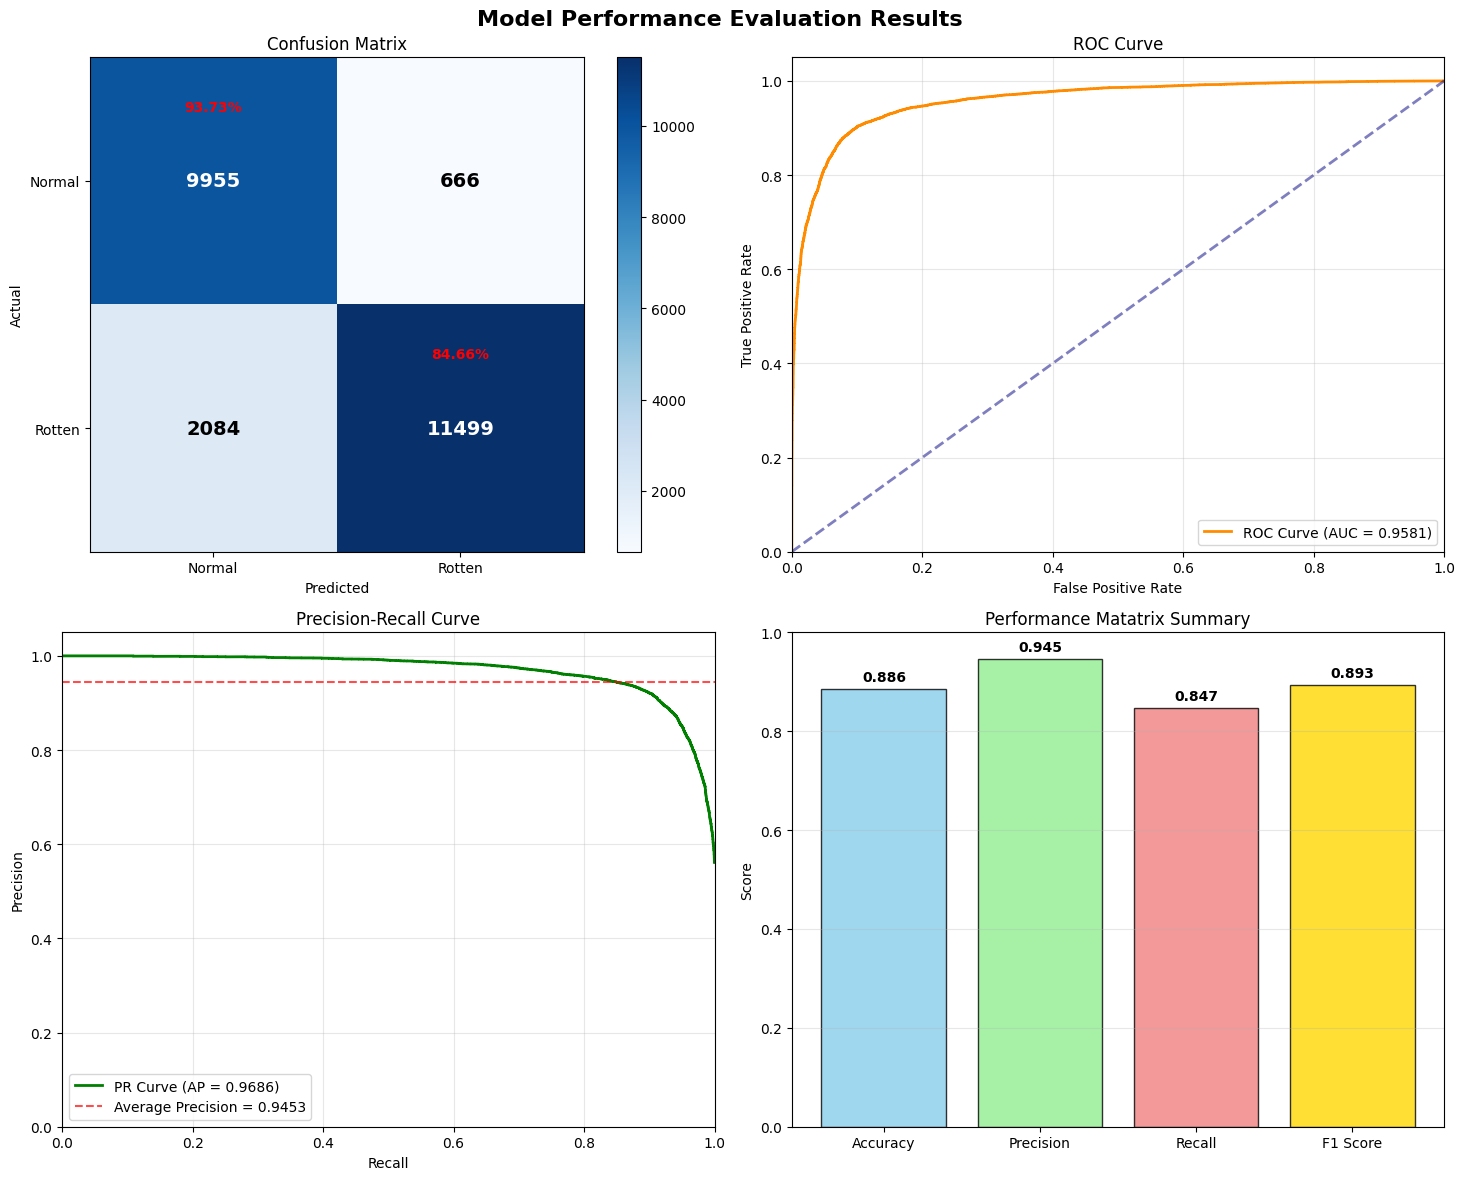


Threshold-based Performance Analysis:
--------------------------------------------------
Threshold  Precision  Recall     F1        
--------------------------------------------------
0.3        0.9090     0.9126     0.9108    
0.4        0.9320     0.8836     0.9072    
0.5        0.9453     0.8466     0.8932    
0.6        0.9562     0.8037     0.8734    
0.7        0.9664     0.7482     0.8434    

Misclassification Analysis:
----------------------------------------
False Positive (Normal->Rotten misclassification): 666 cases
False Negative (Rotten->Normal misclassification): 2084 cases


In [9]:
# confusion matrix 시각화
def plot_confusion_matrix(cm, class_names, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')
    
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    return ax

# 모델 불러오기
model = models.vgg16(pretrained=False)
model.classifier[6] = nn.Linear(in_features=4096, out_features=2)
model.load_state_dict(torch.load("models/best_transfer_VGG_model3.pth"))
model = model3.to(device)
model.eval()

# 결과 분석
def detailed_evaluation(model, test_loader, device):
    model.eval()
    
    # 결과 저장을 위한 리스트
    all_predictions = []
    all_labels = []
    all_probabilities = []
    test_loss = 0.0
    
    criterion = nn.CrossEntropyLoss()
    test_loop = tqdm(test_loader, desc="Testing")
    
    with torch.no_grad():
        for inputs, labels in test_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 확률 계산 - sofmax
            probabilities = F.softmax(outputs, dim=1)
            
            # 예측값
            predictions = outputs.argmax(1)
            
            # 결과 저장
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            test_loss += loss.item() * inputs.size(0)
            test_loop.set_postfix(loss=loss.item())
    
    # numpy 배열로 변환
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    return all_predictions, all_labels, all_probabilities, test_loss / len(all_labels)

# 평가 실행
predictions, true_labels, probabilities, avg_loss = detailed_evaluation(model, test_loader, device)

# 1. 기본 성능 지표 계산
accuracy = (predictions == true_labels).mean()
precision = precision_score(true_labels, predictions, average='binary')
recall = recall_score(true_labels, predictions, average='binary')
f1 = f1_score(true_labels, predictions, average='binary')

# 2. 클래스별 성능 지표
precision_per_class = precision_score(true_labels, predictions, average=None)
recall_per_class = recall_score(true_labels, predictions, average=None)
f1_per_class = f1_score(true_labels, predictions, average=None)

# 3. ROC 커브를 위한 데이터 준비
# 클래스 1 (썩음)에 대한 확률 사용
rotten_probabilities = probabilities[:, 1]
fpr, tpr, thresholds = roc_curve(true_labels, rotten_probabilities)
roc_auc = auc(fpr, tpr)

# 4. Precision-Recall 커브
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(true_labels, rotten_probabilities)
avg_precision = average_precision_score(true_labels, rotten_probabilities)

# 5. 혼동 행렬
cm = confusion_matrix(true_labels, predictions)

# 결과 출력
print("\n" + "="*60)
print("Detailed Model Evaluation Results")
print("="*60)

print(f"Overall Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1 Score:  {f1:.4f}")
print(f"   - Test Loss: {avg_loss:.4f}")

print(f"\nPer-class Performance:")
class_names = ['Normal', 'Rotten']
for i, class_name in enumerate(class_names):
    print(f"   - {class_name:6s} - Precision: {precision_per_class[i]:.4f}, "
          f"Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")

print(f"\nROC & PR Performance:")
print(f"   - ROC AUC: {roc_auc:.4f}")
print(f"   - Average Precision: {avg_precision:.4f}")

# 6. 상세한 분류 리포트
print(f"\Classification result:")
print(classification_report(true_labels, predictions, target_names=class_names))

# 7. 시각화
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Evaluation Results', fontsize=16, fontweight='bold')

# 7-1. 혼동 행렬
ax1 = axes[0, 0]
plot_confusion_matrix(cm, class_names, ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 정확도 정보 추가
for i in range(2):
    for j in range(2):
        if i == j:
            ax1.text(j, i-0.3, f'{cm[i,j]/cm[i,:].sum():.2%}', 
                    ha='center', va='center', color='red', fontweight='bold')

# 7-2. ROC 커브
ax2 = axes[0, 1]
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 7-3. Precision-Recall 커브
ax3 = axes[1, 0]
ax3.plot(recall_curve, precision_curve, color='green', lw=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
ax3.axhline(y=precision, color='red', linestyle='--', alpha=0.7, 
           label=f'Average Precision = {precision:.4f}')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 7-4. 성능 지표 바 차트
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = ax4.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylim([0, 1])
ax4.set_ylabel('Score')
ax4.set_title('Performance Matatrix Summary')
ax4.grid(True, alpha=0.3, axis='y')

# 바 위에 값 표시
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 8. 임계값별 성능 분석
print(f"\nThreshold-based Performance Analysis:")
print("-" * 50)
print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 50)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_thresh = (rotten_probabilities > threshold).astype(int)
    prec_thresh = precision_score(true_labels, pred_thresh)
    rec_thresh = recall_score(true_labels, pred_thresh)
    f1_thresh = f1_score(true_labels, pred_thresh)
    
    print(f"{threshold:<10.1f} {prec_thresh:<10.4f} {rec_thresh:<10.4f} {f1_thresh:<10.4f}")

# 9. 오분류 샘플 분석
print(f"\nMisclassification Analysis:")
print("-" * 40)

# False Positive (정상을 썩음으로 잘못 분류)
fp_indices = np.where((true_labels == 0) & (predictions == 1))[0]
# False Negative (썩음을 정상으로 잘못 분류)  
fn_indices = np.where((true_labels == 1) & (predictions == 0))[0]

print(f"False Positive (Normal->Rotten misclassification): {len(fp_indices)} cases")
print(f"False Negative (Rotten->Normal misclassification): {len(fn_indices)} cases")

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        # 핵심 수정: requires_grad 설정
        input_tensor.requires_grad_(True)
        
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()  # 차원 지정 추가

        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # 디버깅용 출력 (선택사항)
        if self.gradients is None:
            print("ERROR: Gradients are None!")
            return None
            
        pooled_grad = torch.mean(self.gradients, dim=[0, 2, 3])
        activation = self.activations[0]

        for i in range(activation.shape[0]):
            activation[i] *= pooled_grad[i]

        heatmap = activation.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        
        # 0으로 나누는 것 방지
        if np.max(heatmap) > 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

/tmp/ipykernel_428361/1417548691.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/best_transfer_VGG_model3.pth', map_location=dev


=== Rotten Food 분석 ===
예측 결과: Rotten
신뢰도: 85.14%
  Fresh: 14.86%
  Rotten: 85.14%


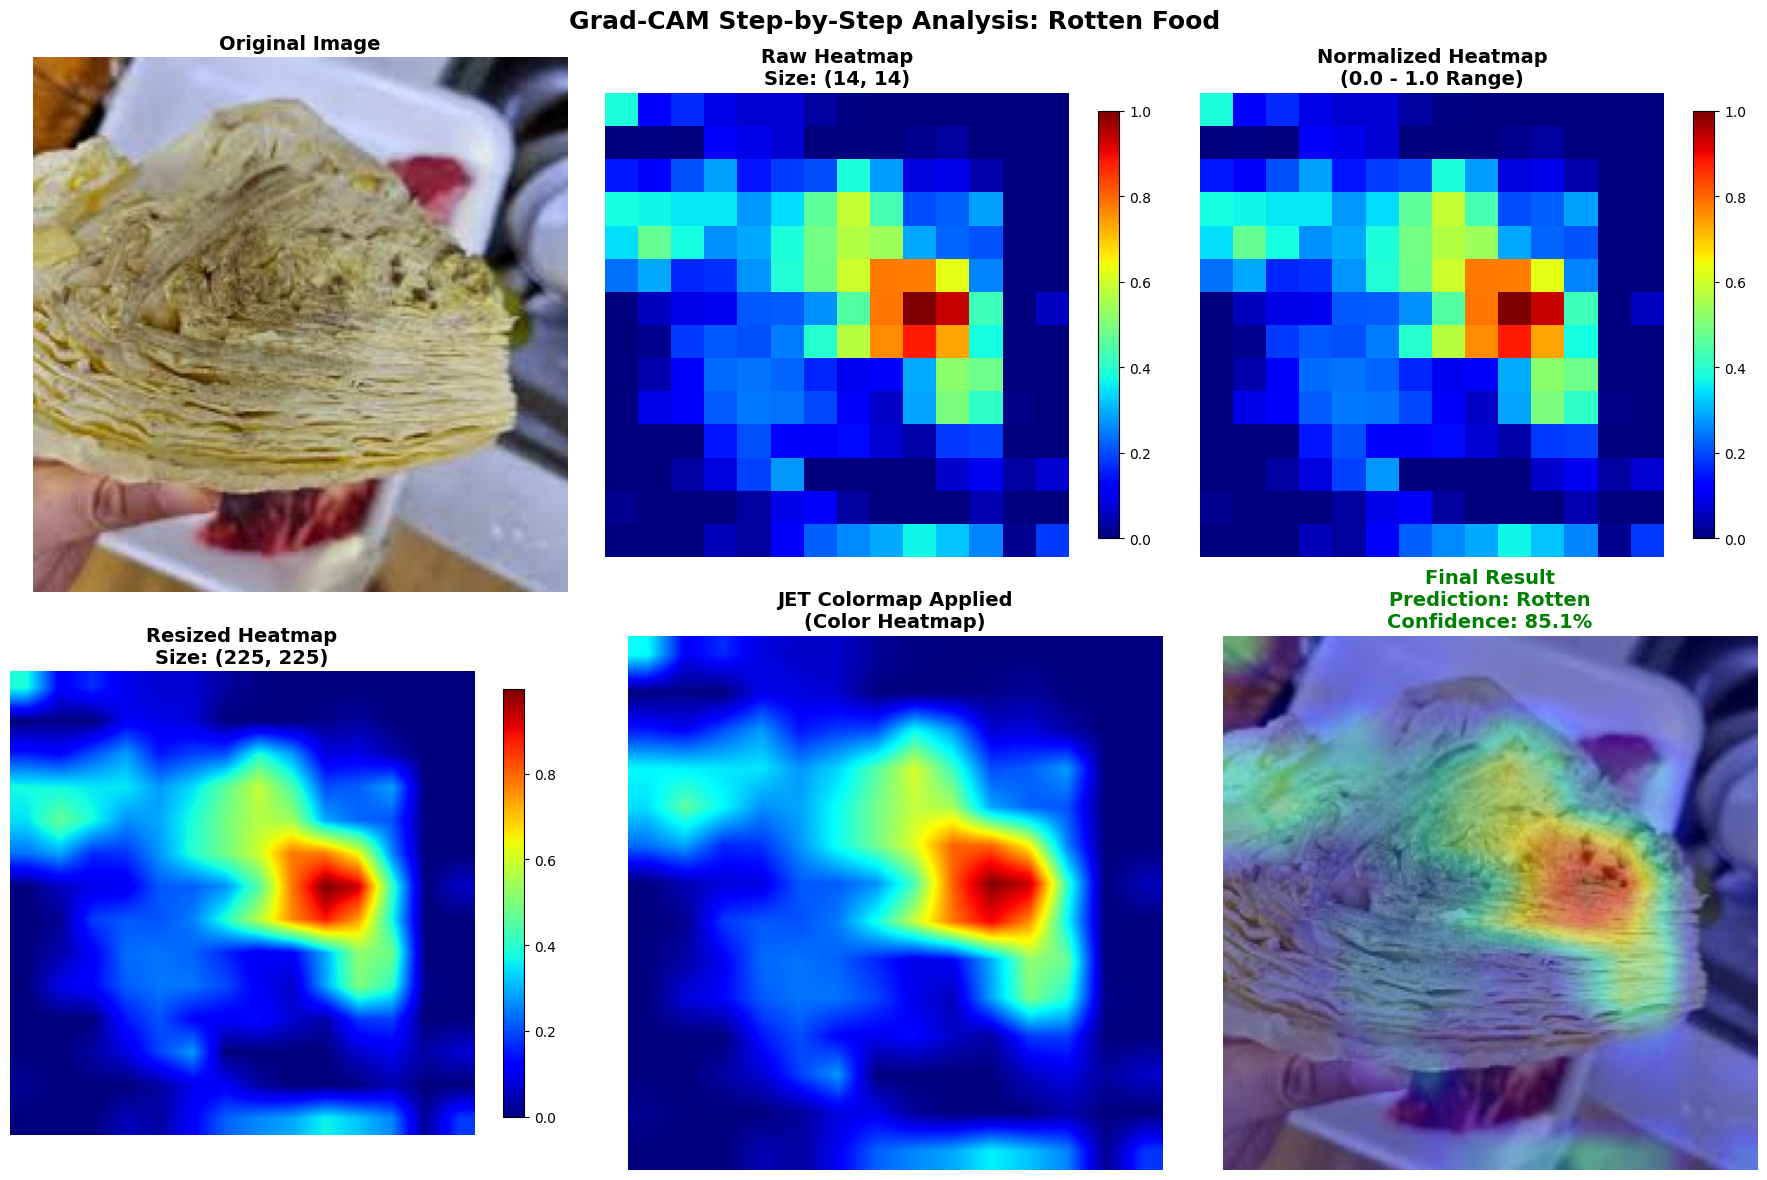


=== Fresh Food 분석 ===
예측 결과: Fresh
신뢰도: 67.63%
  Fresh: 67.63%
  Rotten: 32.37%


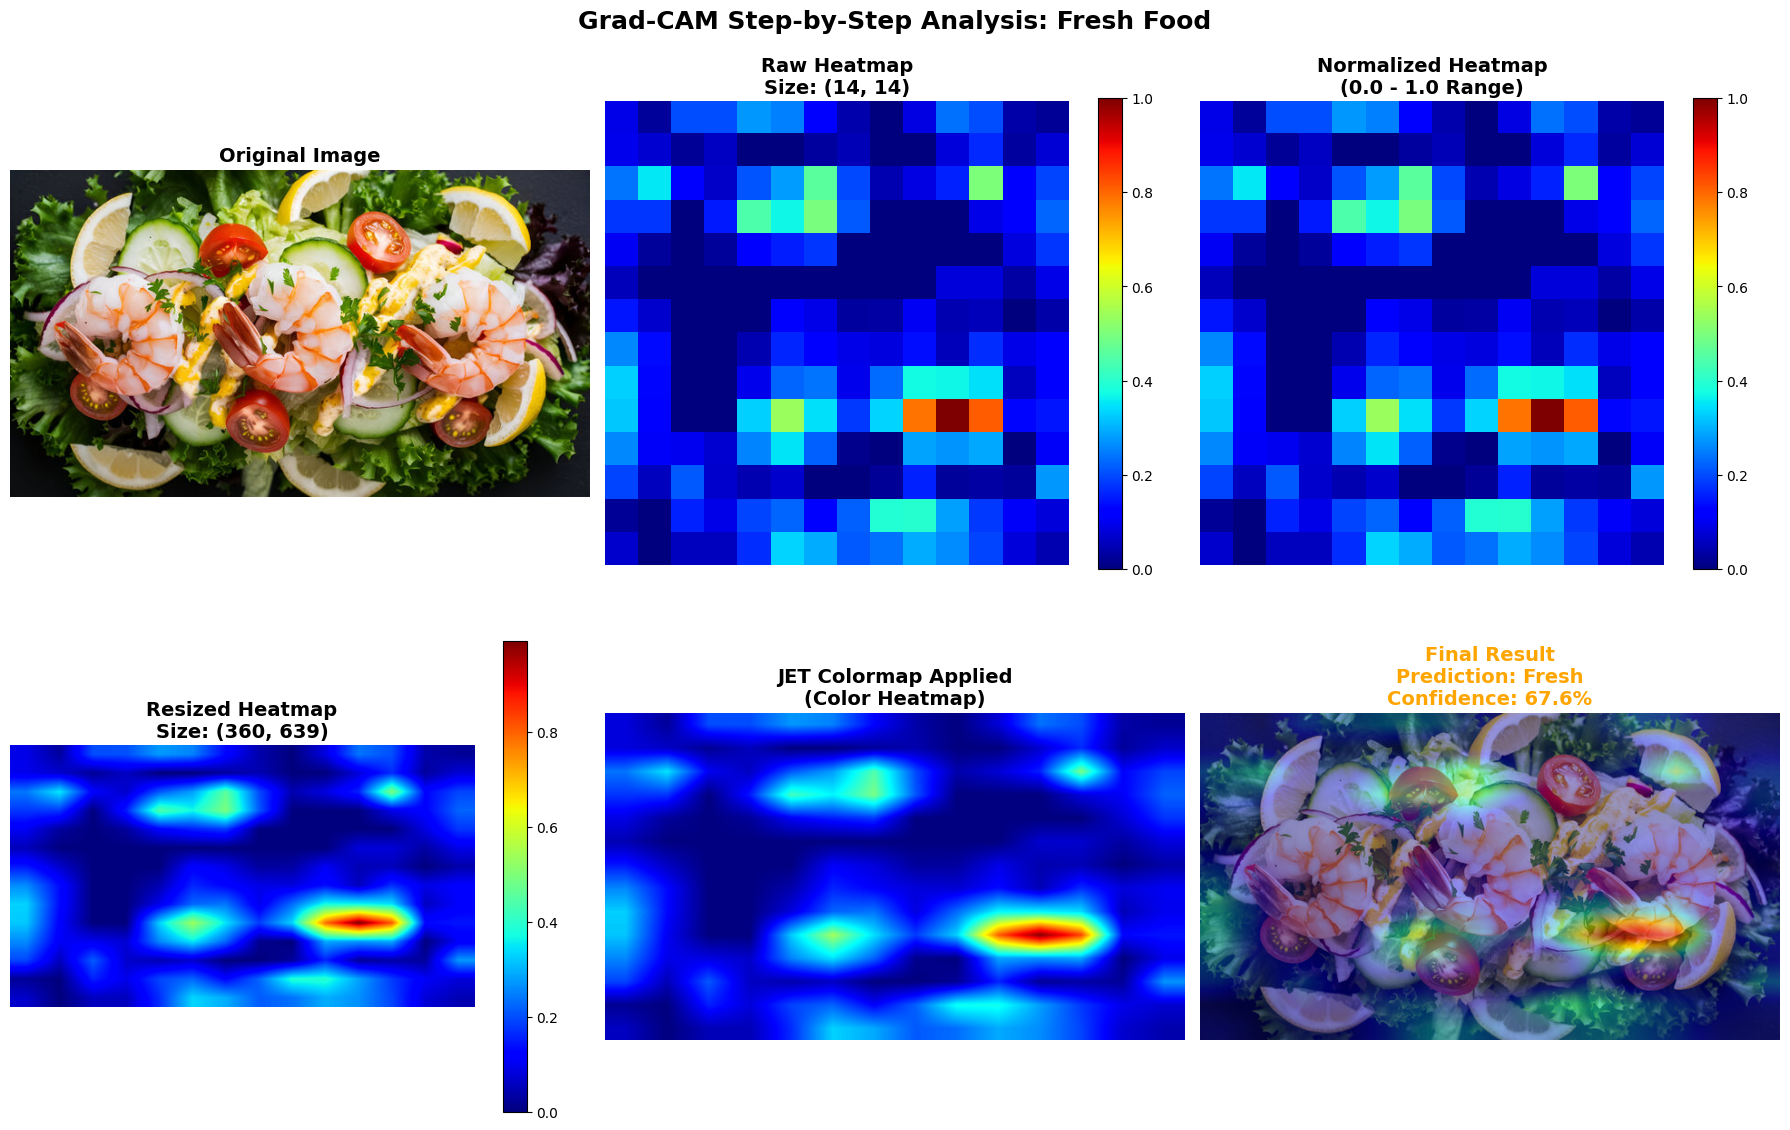

In [27]:
# -----------------------
# 3. Grad-CAM 적용 및 예측
# -----------------------
# 학습된 모델 불러오기
model.load_state_dict(torch.load('models/best_transfer_VGG_model3.pth', map_location=device))
model.eval()

# 클래스 이름 정의
class_names = ['Fresh', 'Rotten']

# 사용할 레이어
target_layer = model.features[28]   # VGG16의 마지막 Conv 블록
grad_cam = GradCAM(model, target_layer)

# 예측 함수 정의
def predict_image(model, input_tensor, class_names):
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
        predicted_class = class_names[predicted.item()]
        confidence_score = confidence.item() * 100
        
        return predicted_class, confidence_score, probabilities[0]

# 3x2 그리드로 Grad-CAM 시각화 함수
def visualize_gradcam_grid(img_path, img_title, model, grad_cam, class_names, device):
    """
    Grad-CAM의 각 단계를 3x2 그리드로 시각화
    """
    print(f"\n=== {img_title} 분석 ===")
    
    # 이미지 전처리 및 예측
    input_tensor, raw_image = preprocess_image(img_path)
    input_tensor = input_tensor.to(device)
    predicted_class, confidence, all_probs = predict_image(model, input_tensor, class_names)
    
    # 결과 출력
    print(f"예측 결과: {predicted_class}")
    print(f"신뢰도: {confidence:.2f}%")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {all_probs[i].item()*100:.2f}%")
    
    # Grad-CAM 생성 및 각 단계별 처리
    heatmap = grad_cam.generate(input_tensor)
    
    # 각 단계별 데이터 준비
    original_image = raw_image  # 원본 이미지
    raw_heatmap = heatmap.copy()  # 모델에서 나온 원시 히트맵
    normalized_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())  # 정규화
    resized_heatmap = cv2.resize(normalized_heatmap, (raw_image.size[0], raw_image.size[1]))  # 리사이즈
    heatmap_uint8 = np.uint8(255 * resized_heatmap)  # 255 스케일 변환
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)  # JET 컬러맵 적용
    raw_image_cv = cv2.cvtColor(np.array(raw_image), cv2.COLOR_RGB2BGR)  # BGR 변환
    final_overlay = cv2.addWeighted(raw_image_cv, 0.6, heatmap_colored, 0.4, 0)  # 최종 오버레이
    
    # 3x2 그리드 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # (1,1) 원본 이미지
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # (1,2) 원시 히트맵
    im1 = axes[0, 1].imshow(raw_heatmap, cmap='jet')
    axes[0, 1].set_title(f'Raw Heatmap\nSize: {raw_heatmap.shape}', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)
    
    # (1,3) 정규화된 히트맵
    im2 = axes[0, 2].imshow(normalized_heatmap, cmap='jet')
    axes[0, 2].set_title('Normalized Heatmap\n(0.0 - 1.0 Range)', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)
    
    # (2,1) 리사이즈된 히트맵
    im3 = axes[1, 0].imshow(resized_heatmap, cmap='jet')
    axes[1, 0].set_title(f'Resized Heatmap\nSize: {resized_heatmap.shape}', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)
    
    # (2,2) 컬러맵 적용
    axes[1, 1].imshow(cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('JET Colormap Applied\n(Color Heatmap)', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    # (2,3) 최종 결과
    axes[1, 2].imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
    color = 'green' if confidence > 80 else 'orange' if confidence > 60 else 'red'
    axes[1, 2].set_title(f'Final Result\nPrediction: {predicted_class}\nConfidence: {confidence:.1f}%', 
                         fontsize=14, fontweight='bold', color=color)
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Grad-CAM Step-by-Step Analysis: {img_title}', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 테스트 이미지들에 대해 3x2 그리드 분석 실행
test_images = [
    ('RottenFood2.jpg', 'Rotten Food'),
    ('FreshFood2.jpg', 'Fresh Food')
]

for img_path, img_title in test_images:
    visualize_gradcam_grid(img_path, img_title, model, grad_cam, class_names, device)